# Sparse Methods: Sparse PCA and Independent Component Analysis

## Overview

Standard PCA produces dense loadings — every variable contributes to every component. This makes components difficult to interpret when p is large. **Sparse PCA** adds an L1 penalty to loadings, forcing most to exactly zero: each component is defined by a small subset of variables.

**Independent Component Analysis (ICA)** finds components that are statistically independent (not just uncorrelated). Where PCA maximises variance, ICA maximises non-Gaussianity — recovering the original source signals from mixed observations.

**When to use each:**

| Method | Use when |
|---|---|
| **Standard PCA** | Dimensionality reduction; visualisation; p moderately large |
| **Sparse PCA** | p >> n; interpretability required; variable selection via loadings |
| **ICA** | Mixed signals with non-Gaussian sources; signal separation; fMRI, EEG, remote sensing |

**Sparse PCA vs. LASSO:** LASSO applies sparsity to regression coefficients; sparse PCA applies sparsity to PCA loadings. Both use L1 regularisation but solve different optimisation problems.

---

## Setup

In [6]:
library(tidyverse)
library(ggplot2)
library(sparsepca)     # spca() — sparse PCA via elastic net
library(PMA)           # SPC() — sparse PCA via LASSO (Witten et al.)
library(fastICA)       # fastICA()
library(factoextra)
library(patchwork)

set.seed(42)

# ── High-dimensional dataset: 200 sites, 40 environmental variables ───────────
# Only 6 variables carry real signal; the rest are noise
n  <- 200
p  <- 40

# Two latent factors
f1 <- rnorm(n)  # nutrient gradient: drives vars 1-6
f2 <- rnorm(n)  # hydrological stress: drives vars 7-12

X_signal <- matrix(0, n, p)
X_signal[, 1:6]  <- outer(f1, c(0.9, 0.85, 0.80, 0.75, 0.70, 0.65))
X_signal[, 7:12] <- outer(f2, c(0.9, 0.85, 0.80, 0.75, 0.70, 0.65))
X_noise  <- matrix(rnorm(n * p, 0, 0.8), n, p)
X_raw    <- X_signal + X_noise
X_sc     <- scale(X_raw)

colnames(X_sc) <- c(paste0("nutrient_", 1:6),
                    paste0("hydro_", 1:6),
                    paste0("noise_", 1:28))
cat(sprintf("%d observations × %d features (%d signal + %d noise)\n",
            n, p, 12, 28))

Welcome! Want to learn more? See two factoextra-related books at https://goo.gl/ve3WBa

Warning message:
"package 'patchwork' was built under R version 4.4.3"


200 observations × 40 features (12 signal + 28 noise)


---

## Standard PCA vs. Sparse PCA: Loadings Comparison


Standard PCA PC1: 40 non-zero loadings
Sparse PCA PC1:   40 non-zero loadings


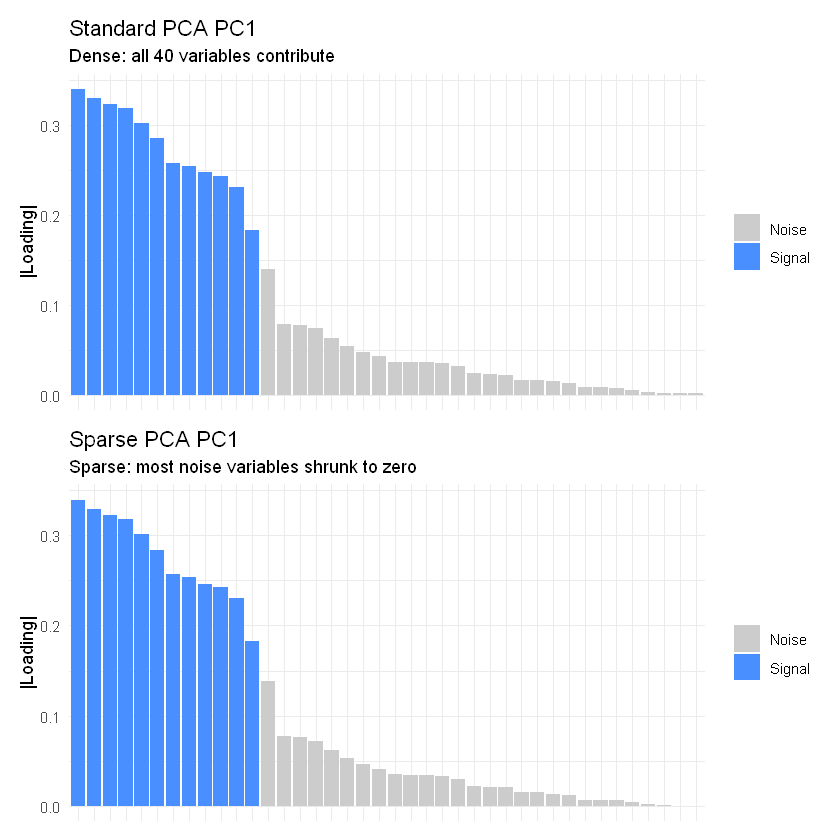

In [7]:
# ── Standard PCA ──────────────────────────────────────────────────────────────
pca_fit <- prcomp(X_sc, center=FALSE)

# ── Sparse PCA (sparsepca::spca) ─────────────────────────────────────────────
# alpha: L1 sparsity penalty (larger = more zeros)
# beta:  L2 ridge penalty (stabilises when p > n)
# k:     number of components
spca_fit <- sparsepca::spca(
  X_sc,
  k     = 2,
  alpha = 1e-3,   # start small; tune to get interpretable sparsity
  beta  = 1e-4,
  center = FALSE,
  scale  = FALSE,
  verbose = FALSE
)

# Compare: which variables load on PC1?
loading_comparison <- tibble(
  variable   = colnames(X_sc),
  pca_pc1    = abs(pca_fit$rotation[, 1]),
  spca_pc1   = abs(spca_fit$loadings[, 1]),
  is_signal  = str_starts(variable, "nutrient") | str_starts(variable, "hydro")
)

p_dense <- ggplot(
  loading_comparison %>% arrange(desc(pca_pc1)) %>%
    mutate(variable=fct_inorder(variable)),
  aes(x=variable, y=pca_pc1, fill=is_signal)
) +
  geom_col() +
  scale_fill_manual(values=c("TRUE"="#4a8fff","FALSE"="#cccccc"),
                    labels=c("TRUE"="Signal","FALSE"="Noise")) +
  labs(title="Standard PCA PC1", subtitle="Dense: all 40 variables contribute",
       x=NULL, y="|Loading|", fill=NULL) +
  theme_minimal() +
  theme(axis.text.x=element_blank())

p_sparse <- ggplot(
  loading_comparison %>% arrange(desc(spca_pc1)) %>%
    mutate(variable=fct_inorder(variable)),
  aes(x=variable, y=spca_pc1, fill=is_signal)
) +
  geom_col() +
  scale_fill_manual(values=c("TRUE"="#4a8fff","FALSE"="#cccccc"),
                    labels=c("TRUE"="Signal","FALSE"="Noise")) +
  labs(title="Sparse PCA PC1", subtitle="Sparse: most noise variables shrunk to zero",
       x=NULL, y="|Loading|", fill=NULL) +
  theme_minimal() +
  theme(axis.text.x=element_blank())

(p_dense / p_sparse)

cat(sprintf("\nStandard PCA PC1: %d non-zero loadings\n",
            sum(abs(pca_fit$rotation[,1]) > 1e-10)))
cat(sprintf("Sparse PCA PC1:   %d non-zero loadings\n",
            sum(abs(spca_fit$loadings[,1]) > 1e-10)))

---

## Tuning Sparsity: Choosing Alpha

# A tibble: 0 × 4
# ℹ 4 variables: alpha <dbl>, nonzero_pc1 <int>, nonzero_pc2 <int>,
#   pct_var_pc1 <dbl>


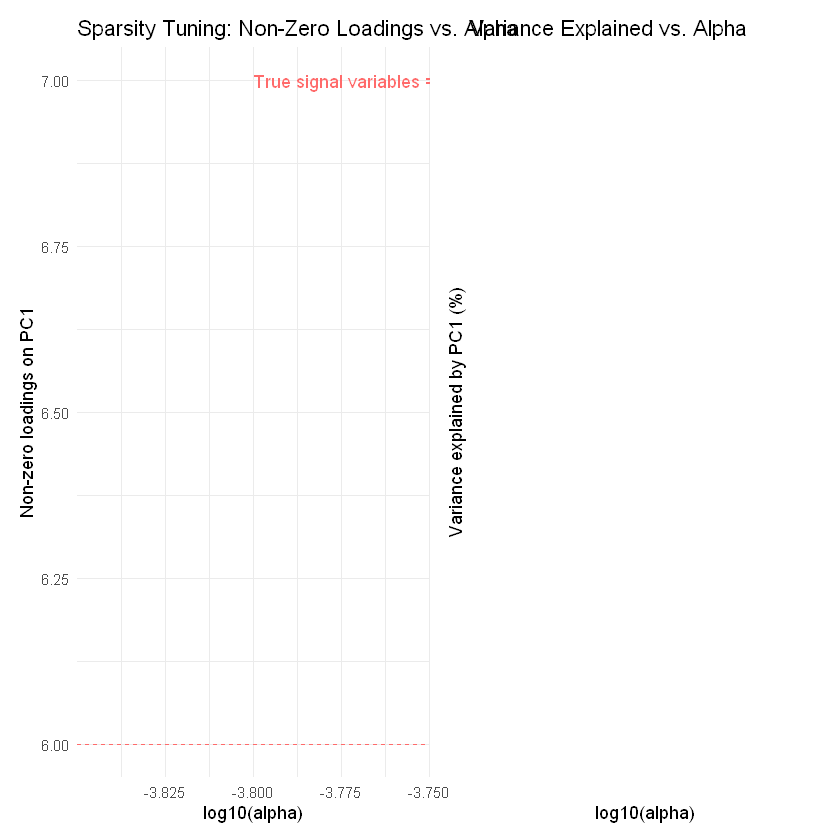

In [8]:
# Trade-off: more sparsity (larger alpha) → fewer variables, less variance explained
alpha_grid <- c(1e-4, 5e-4, 1e-3, 5e-3, 1e-2, 5e-2)

alpha_results <- map_dfr(alpha_grid, function(a) {
  fit <- sparsepca::spca(X_sc, k=2, alpha=a, beta=1e-4,
                          center=FALSE, scale=FALSE, verbose=FALSE)
  tibble(
    alpha       = a,
    nonzero_pc1 = sum(abs(fit$loadings[,1]) > 1e-10),
    nonzero_pc2 = sum(abs(fit$loadings[,2]) > 1e-10),
    pct_var_pc1 = fit$R2[1] * 100
  )
})

print(alpha_results)

p_nonzero <- ggplot(alpha_results, aes(x=log10(alpha), y=nonzero_pc1)) +
  geom_line(color="#4a8fff", linewidth=1) +
  geom_point(size=3, color="#4a8fff") +
  geom_hline(yintercept=6, linetype="dashed", color="#ff6b6b") +
  annotate("text", x=min(log10(alpha_grid))+0.2, y=7,
           label="True signal variables = 6", color="#ff6b6b", hjust=0) +
  labs(title="Sparsity Tuning: Non-Zero Loadings vs. Alpha",
       x="log10(alpha)", y="Non-zero loadings on PC1") +
  theme_minimal()

p_var <- ggplot(alpha_results, aes(x=log10(alpha), y=pct_var_pc1)) +
  geom_line(color="#ff6b6b", linewidth=1) +
  geom_point(size=3, color="#ff6b6b") +
  labs(title="Variance Explained vs. Alpha",
       x="log10(alpha)", y="Variance explained by PC1 (%)") +
  theme_minimal()

(p_nonzero | p_var)

---

## Independent Component Analysis (ICA)

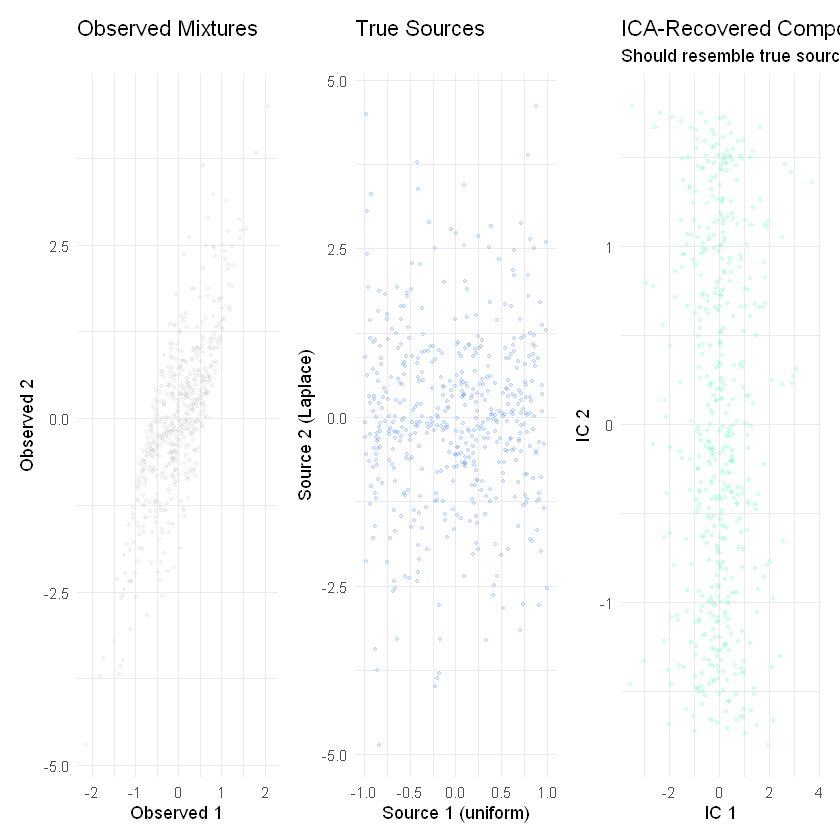

In [9]:
# ICA assumes observed variables are linear mixtures of independent sources
# It recovers statistically independent (non-Gaussian) components
# Unlike PCA components (uncorrelated), ICA components are independent

# Simulate: two clearly non-Gaussian sources
n_ica  <- 500
s1 <- runif(n_ica, -1, 1)       # uniform distribution
s2 <- sign(rnorm(n_ica)) * rexp(n_ica, 1)  # Laplace-like (super-Gaussian)
S  <- cbind(s1, s2)

# Mixing matrix
A  <- matrix(c(0.8, 0.4, 0.3, 0.9), 2, 2)
X_mixed <- t(A %*% t(S))  # observed mixtures

# ICA: recover independent sources from mixtures
ica_fit <- fastICA::fastICA(
  X_mixed,
  n.comp  = 2,
  alg.typ = "parallel",
  fun     = "logcosh",   # contrast function; alternatives: 'exp', 'kurtosis'
  verbose = FALSE
)

# Compare original sources to recovered components
source_df <- tibble(
  s1_true = S[,1], s2_true = S[,2],
  ic1     = ica_fit$S[,1], ic2 = ica_fit$S[,2],
  obs1    = X_mixed[,1],   obs2 = X_mixed[,2]
)

p_mixed <- ggplot(source_df, aes(x=obs1, y=obs2)) +
  geom_point(alpha=0.2, size=0.8, color="#cccccc") +
  labs(title="Observed Mixtures", x="Observed 1", y="Observed 2") +
  theme_minimal()

p_sources <- ggplot(source_df, aes(x=s1_true, y=s2_true)) +
  geom_point(alpha=0.2, size=0.8, color="#4a8fff") +
  labs(title="True Sources", x="Source 1 (uniform)", y="Source 2 (Laplace)") +
  theme_minimal()

p_recovered <- ggplot(source_df, aes(x=ic1, y=ic2)) +
  geom_point(alpha=0.2, size=0.8, color="#4fffb0") +
  labs(title="ICA-Recovered Components",
       subtitle="Should resemble true sources (up to sign and scale)",
       x="IC 1", y="IC 2") +
  theme_minimal()

(p_mixed | p_sources | p_recovered)

---

## Common Pitfalls

**1. Choosing sparsity penalty alpha without examining the sparsity–variance trade-off**  
There is no automatic rule for choosing alpha in sparse PCA. Too small and loadings remain dense; too large and all variance is eliminated. Always plot non-zero loadings and variance explained against a range of alpha values, and select the value where the curve elbows — fewest variables needed to explain acceptable variance.

**2. Treating sparse PCA components as if variance-explained statistics from standard PCA apply**  
Sparse components are not orthogonal and do not partition variance cleanly. The variance explained by sparse components is not additive in the same way as PCA. Use the R² reported by `spca()` per component as an approximation, but do not sum them without accounting for overlap.

**3. Applying ICA to data with Gaussian sources**  
ICA identifies components by maximising non-Gaussianity. If the true sources are Gaussian, they are inherently unidentifiable by ICA — any rotation of the PCA solution is equally valid. ICA only provides a unique solution when sources are non-Gaussian. Check the marginal distributions of ICA components after fitting.

**4. Ignoring ICA sign and permutation ambiguity**  
ICA components are identified only up to sign (±) and ordering. The signs of ICA components are arbitrary — IC1 in one run may appear as −IC1 in another. Never interpret the sign of an ICA component without anchoring it to a reference variable or running multiple initialisations and aligning components.

**5. Using sparse PCA when n < p without ridge regularisation**  
When observations are fewer than variables, standard and sparse PCA can be numerically unstable. Always add a small ridge penalty (`beta > 0` in `spca()`) when p ≥ n to stabilise the solution. The ridge penalty shrinks loadings toward zero without enforcing exact sparsity — it complements the L1 sparsity penalty.

---
*r_methods_library · Samantha McGarrigle · [github.com/samantha-mcgarrigle](https://github.com/samantha-mcgarrigle)*